In [52]:
# Cell 1: Imports and Helper Functions
import json
import matplotlib.pyplot as plt
from PIL import Image
import os
import json
import random
import numpy as np

qa_file = "/mnt/bn/nlhei-nas/liubangya/proj/vlm/workspace/scannet_400/image_scannetpp_new_16x24_5/pairs/QA_pairs_qwen.test.json"

# Helper function to display image
def display_image(img_path, title=None):
    if isinstance(img_path, str):
        img = Image.open(img_path)
        num_img = 1
    else:
        imgs = []
        all_rows = []
        max_img_per_row = 3
        for p in img_path:
            img = Image.open(p)
            imgs.append(img)
        for i in range(0, len(imgs), max_img_per_row):
            imgs_per_row = imgs[i:i+max_img_per_row]
            if len(imgs_per_row) < max_img_per_row:
                imgs_per_row = imgs_per_row + [np.zeros_like(imgs_per_row[0])] * (max_img_per_row - len(imgs_per_row))

            imgs_per_row = [np.array(img) for img in imgs_per_row]
            imgs_per_row = np.concatenate(imgs_per_row, axis=1)
            all_rows.append(Image.fromarray(imgs_per_row))

        img = np.concatenate(all_rows, axis=0)

    plt.figure(figsize=(10 * max_img_per_row, 10))
    plt.imshow(img)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

# Helper function to pretty print conversation
def show_conversation(conversations):
    for turn in conversations:
        if turn['from'] == 'human':
            print("Q:", turn['value'].replace("<image>","").strip())
        else:
            print("A:", turn['value'].replace("<image>","").strip())

with open(qa_file, "r") as f:
    qa_data = json.load(f)


visualize qa 1192


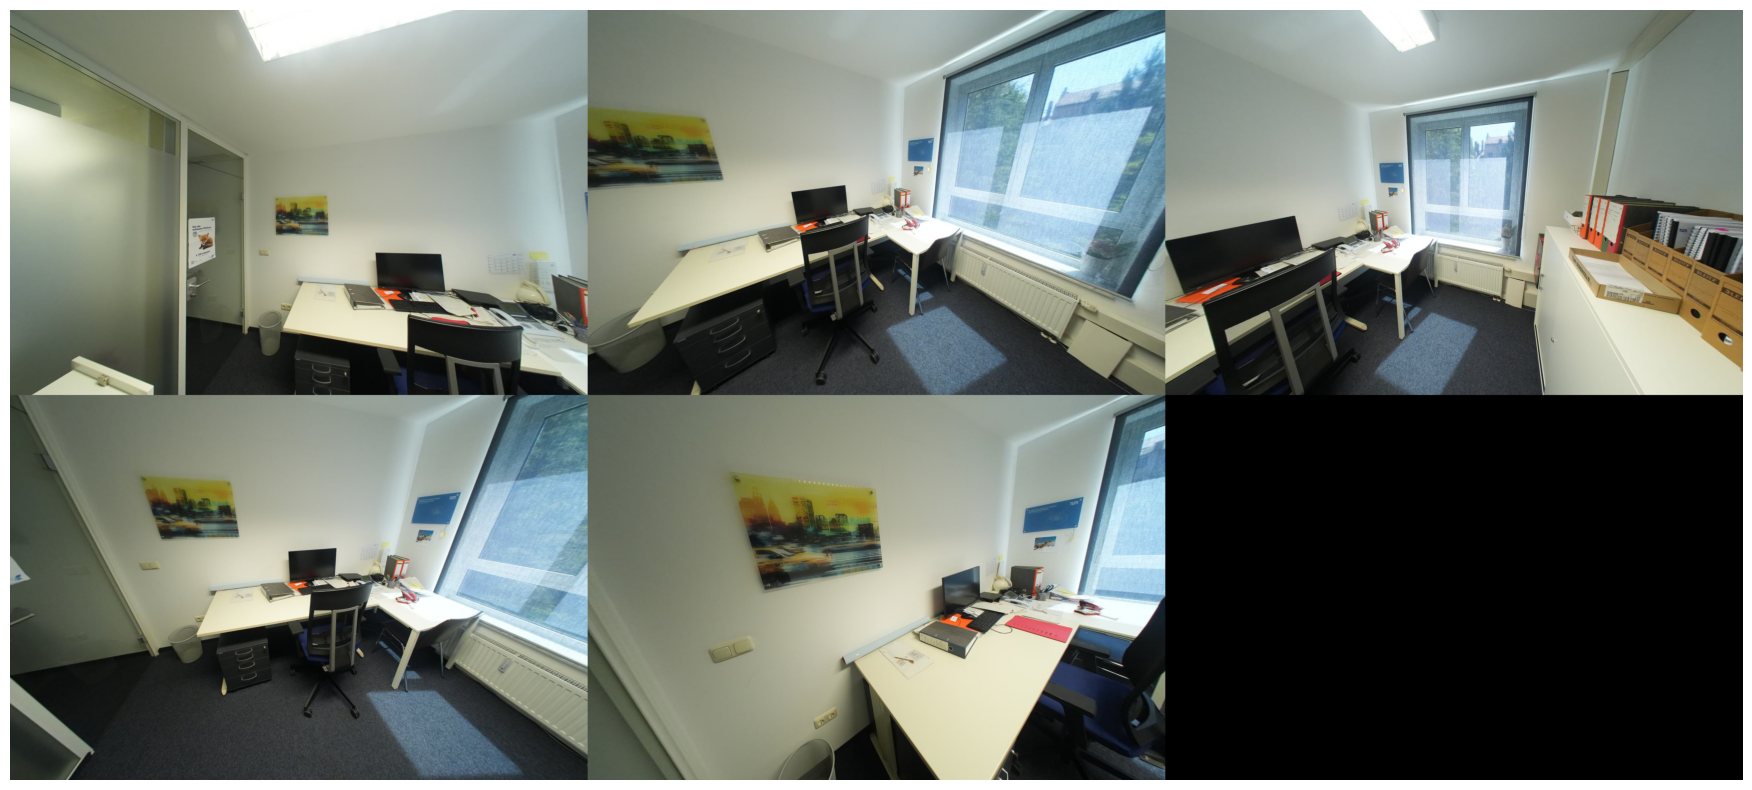

Q: The above frames are captured from the same 3D object or 3D scene yet from different viewpoints.
        Lets patchify each frame into 16 rows and 24 columns, 
        and the origin is at the top-left corner of each frame. 
        We could index each patch by its row and col in the format of (row, col).
        Indexing range of row are of 0 ~ 15,
        indexing range of col are of 0 ~ 23.
        You are an expert of multiview stereo. try your best to answer this question:
            We could notice that the paper is centered at patch (11, 13) in the very first frame.
            Try to track the same object across all the following frames. Simply return the patch index of that object at each frame. 
            In your final answer also include the patch index of that object in the first frame.
            
            Directly reply the patch indexes in each frame in the format of "frame row col, frame row col, ..."
            For example: 0 3 5, 1 7 9, 2 3 2
            Fr

In [53]:

q = random.choice(qa_data)
# q = qa_data[1259]
img_path = q['image']

print(f"visualize qa {q['id']}")
display_image(img_path)
show_conversation(q['conversations'])
print("="*80)
